#### Exponential Time Differencing  
Created May 7, 2026

In this notebook we implement the Exponential Time-Differencing (ETD) method for solving ODE systems of the form 
#### 
\begin{align*}
    u_t = Au + f(u,t)
\end{align*}

where $A$ is an $N \times N$ constant matrix and $f:\mathbb{R}^{N} \times \mathbb{R} \to \mathbb{R}$ is some non-linear function. ETD methods are especially useful for ODEs of the above form, as the linear term $Au$ often makes the ODE system stiff; ETD handles this by "integrating the linear part exactly" (in a sense discussed below). More precisely, ETD makes use of the following *variation of parameters* formula: 
\begin{align*}
    \fbox{$u(t_{n+1}) = e^{\Delta t A} u_n + \int_{t_n}^{t_{n+1}} e^{(t_{n+1} - s)A} f(u(s),s)ds \,$}
\end{align*}

A fixed-step ETD scheme is just a scheme of the form 
\begin{align*}
   \qquad u_{n+1} = e^{\Delta t A} u_n + I_n, \qquad n = 0,1,2,\ldots
\end{align*}
where $I_n = I_n(u_n,\ldots,u_{n-k})$ is an approximation to the integral term. ETD Euler is obtained by making the approximation $f(u(\cdot),\cdot) \approx f(u(t_n), t_n))$ on $[t_{n},t_{n+1}]$: 
\begin{align*}
    I_n \approx \left(\int_{t_n}^{t_{n+1}} e^{(t_{n+1} - s)A}\right) f(u_n,t_n) = \left(\int_{0}^{\Delta t} e^{sA} \,ds \right) f(u_n,t_n). 
\end{align*}

The last integral can be expressed as a series: 
\begin{align*}
    \int_{0}^{\Delta t} e^{sA} \,ds = \int_{0}^{\Delta t} \sum_{k=0}^{\infty} \frac{(sA)^k}{k!} \,ds = \sum_{k=0}^{\infty} \int_{0}^{\Delta t}  \frac{(sA)^k}{k!} \,ds = \sum_{k=0}^{\infty} \frac{(\Delta t)^{k+1}A^k}{(k+1)!} = \Delta t \underbrace{\left(\sum_{k=0}^{\infty} \frac{(\Delta t A)^k}{(k+1)!}\right)}_{=:\varphi_1(\Delta t A)}
\end{align*}

The last series in the above line is the definition for the matrix-valued function $\varphi_1: \mathbb{R}^{n \times n} \to \mathbb{R}^{n \times n}$, which comes up frequently in ETD schemes (along with other so-called *phi-functions*). Note that if $z$ is a scalar, then 
\begin{align*}
   z \varphi_1(z) = \sum_{k=0}^{\infty} \frac{z^{k+1}}{(k+1)!} = \sum_{k=1}^{\infty} \frac{z^k}{k!} = e^z - 1
\end{align*}
and so 
\begin{align*}
   \varphi_1(z) = \frac{e^z - 1}{z} \quad \text{for } z \in \mathbb{R} \text{ or } \mathbb{C}. 
\end{align*}

Thus, the ETD Euler scheme in terms of $\varphi_1$ is: 
\begin{align*}
   \textbf{ETD Euler:} \quad \fbox{$\displaystyle u_{n+1} = u_n e^{\Delta t A} + \Delta t \, \varphi_1(\Delta t A) f(u_n,t_n)$}
\end{align*}

Or assuming that $A$ is invertible, 
\begin{align*}
    \fbox{$\displaystyle u_{n+1} = u_n e^{\Delta t A} + A^{-1} (e^{\Delta t A} - I) f(u_n,t_n)$}
\end{align*}

**Remarks:** 
- The matrix inverse $A^{-1}$ can be computed once at the outset. This shouldn't be a problem.  
- We have to compute the matrix exponentials $e^{\Delta t A}$ at every time step, which is expensive. Don't try using a Taylor series approximation;
- It's better to use some specialized tools for this, such as `ExponentialUtilities.jl`. 


<!--
In the ETD schemes we will make use of the following functions:
\begin{align}
 \varphi_1(z) = \frac{e^z - 1}{z}, \qquad \varphi_2(z) = \frac{e^z - 1 - z}{z^2}. 
\end{align}

The **ETD-Euler scheme**: 
\begin{align*}
adf
\end{align*}

We implement the so-called **ETD2RK** scheme from Cox and Matthews (2002): 
\begin{flalign*}
   a &= e^{L \Delta t} u^n + \Delta t \varphi_1(L \Delta t) f(u^n, t^n) &&  \\[4pt]
   u^{n+1} &= a + \Delta t \varphi_2(L \Delta t) \left[f(a,t^{n+1}) - f(u^n,t^n) \right]  && 
\end{flalign*}
-->

In [9]:
using OrdinaryDiffEq, CairoMakie, LaTeXStrings, Printf, UnPack, NBInclude, Roots, LinearAlgebra, Random, Statistics, ExponentialUtilities, FFTW
@nbinclude("..//set_makie_defaults.ipynb")
@nbinclude("phi_functions.ipynb")

In [1]:
function phi1(z::Number; ϵ = 1e-14)
    #Computes φ₁(z) := (e^z - 1)/z  for z ≠ 0, φ_1(0) = 1 
    if abs(z) < ϵ
        return one(z)
    else 
        return expm1(z) / z    #expm1(z) = e^z - 1 (but computes it in a way that avoids cancellation error) 
    end 
end

function phi1(B::AbstractMatrix)
    """
    Computes the matrix-valued expression ∑_{k=0}^{infty} B^k/(k+1)! = I + B/2! + B^2/3! + B^3/4! + ... 
    Instead of truncating the series above, we use a trick based on properties of the matrix exponential for block matrices. 
    """

    T = promote_type(eltype(B), Float64)                  #T is a common type suitable for mixed arithmetic (between the elements of M and Float64's) 
    n, m = size(B)    
    n == m || throw(ArgumentError("B must be square!"))   #Check that B is a square matrix. 

    Z = zeros(T, n, n)        #Create n x n zero matrix (of eltype T) 
    Iₙ = Matrix{T}(I, n, n)   #Create n x n identity matrix (of eltype T)  

    M = [B Iₙ
         Z Z]

    expM = exp(M)   #Compute the matrix exponential (using the exp() function from LinearAlgebra.jl) 
    return expM[1:n,n+1:end]
    
    """
    NOTE: `promote_type(eltype(M), Float64)` means the following: 
    "Choose a numeric type capable of handling mixed arithmetic between the entries of B and ordinary Float64's. 

    Why do we need this? If eltype(M) is already Float64, then we don't actually need this line. But eltype(M) could be something else,
    such as Int, or ComplexF64. When constructing the block matrix, we need to ensure that it's eltype is one that 
    is suitable for mixed arithmetic with Float64's, as arithmetic involving Float64's will happen due to Juila's exp implementation, 
    which internally uses algorithms involving:
    - scaling,
    - Padé approximants,
    - matrix norms,
    - divisions by factorial-like constants,
    - repeated squaring,
    all of which naturally involve floating-point arithmetic.
    """
end 

discrete_lp_norm(u, Δt; p = 2)  = norm(u,p) * (Δt)^(1/p)

discrete_lp_norm (generic function with 1 method)

In [10]:
function etd_euler(A, f, u0; Δt, tspan, p = nothing)
    """
    Solves the ODE u_t = Au + f(u,p,t)  on [tspan[1], tspan[2]] using the ETD-Euler method where: 
    - u: [t0,tf] -> R^N is the ODE solution
    - A is an N x N constant matrix 
    - f is a nonlinear function from R^N × [t0,tf] to R^N
    - p an optional parameter for the function 'f' (must be included in the function signature though) 
    
    PARAMETERS
    ----------
    A :: N x N matrix (or a scalar) 
    f :: a function `f(u,p,t)` from R^N to R (the non-linear term) where u is the state, p is a scalar, and t is time. 
    u0 :: the initial condition; a scalar (if N = 1) or a vector (if N > 1) 
    Δt :: the time step 
    tspan :: time interval over which to integrate (a tuple) 
    p :: parameter tuple for the reaction term (if required) 
    
    RETURNS
    -------
    sol.u :: vector of solution iterates 
    sol.t :: time values at which the solution was computed 
    sol.Δt :: the time step 
    """

    t0, tf = tspan                                         #Endpoints of time interval
    num_steps = Int(floor((tf - t0)/Δt))                   #Number of steps to be taken by the ODE solver 
    num_save = num_steps + 1                               #Number of solution iterates to save (****INCLUDES THE INITIAL CONDITION, `u0`****) 
    t = collect(range(t0, step = Δt, length = num_save))   #Time values at which to record the solution 
                                                           #NOTE: t = [t_0, t_1,...,t_M], where t_i = t_0 + iΔt for i=0,1,...,M, where M := num_steps 
    
    u = [zero(u0) for _ in 1:num_save]            #Initialize array to store the solution u [Note: u = [u[1],...,u[M+1]]
    u[1] = u0                                    #Record the initial condition  
    
    #Compute the necessary matrices 
    #E = exp(Δt*A)
    #Φ₁ = phi1(Δt*A) 

    E, Φ₁ = phis(Δt*A, 1)
    
  
    for j=1:num_steps     #j+1 = 2,3,...,num_save 
        u[j+1] = E * u[j] + Δt * (Φ₁ * f(u[j], p, t[j]))
    end 

    return (u = u, t = t, Δt = Δt) 
end 

etd_euler (generic function with 1 method)

#### **ETD Euler: Test 1**


##### **ODE: $\displaystyle u' = -au + u^2, \quad u(0) = u_0, \quad 0 < u_0 < a$**

##### **Exact Solution:**  $\quad \displaystyle u(t) = \frac{a}{1 - \left(1 - \frac{a}{u_0} \right)e^t}$

- We have $A = -a$ and $f(u,t) = u^2$
- Note that $\lim\limits_{t \to \infty} u(t) = 0$, provided $a > 0$. 

  0.000010 seconds (1 allocation: 16 bytes)
Discrete Lp Error: 2.0562e-03

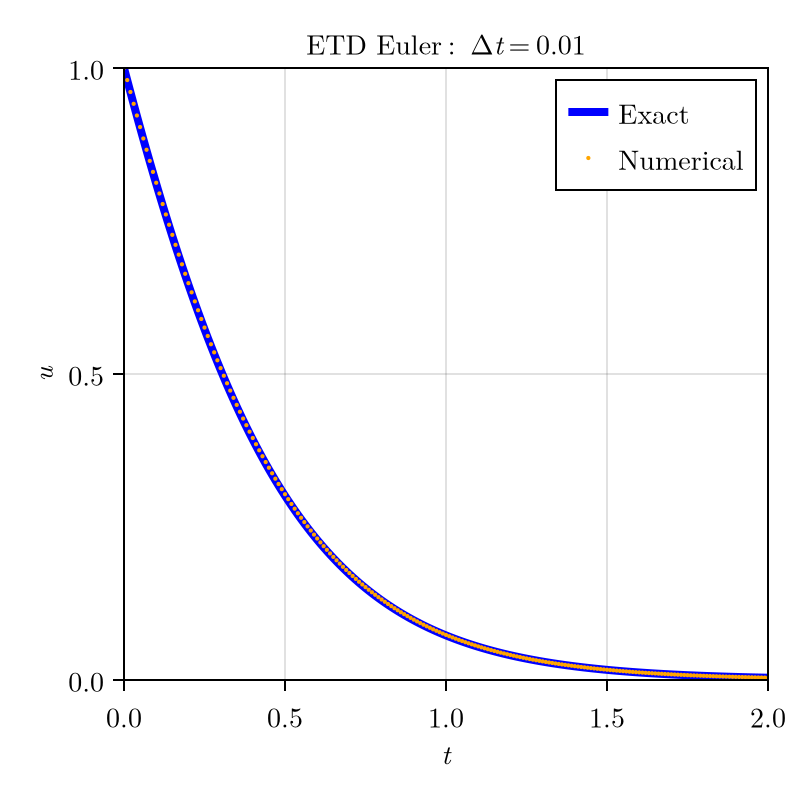

CairoMakie.Screen{IMAGE}


In [12]:
#Test ETD Euler using a *scalar* equation
a = 3.0 
u0 = 1.0 

Δt = 0.01
tf = 2.0 
u_exact(t,a,u0) = a ./ (1.0 - (1.0 - a/u0)*exp(a*t))

A = -a 
f(u,p,t) = u^2 

sol = etd_euler(A, f, u0; Δt = 0.01, tspan = (0,tf), p = nothing)
@time @unpack u, t, Δt = sol

fig = Figure(size = (400, 400))
ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"u", limits = (0,tf,0,1), title = L"\textrm{ETD Euler: } Δt = %$(Δt)")
lines!(ax, t, u_exact.(t,a,u0), color = :blue, label = "Exact", linewidth = 4)
scatter!(ax, sol.t, sol.u, markersize = 3, color = :orange, label = "Numerical")
axislegend(ax, position = :rt)

err = discrete_lp_norm(u_exact.(sol.t,a,u0) .- sol.u, Δt, p = 2)
@printf("Discrete Lp Error: %.4e", err)
display(fig)

#### **ETD Euler: Test 2** 
$$A = \begin{pmatrix} -100 & \phantom{-}0 \\ 0 & -1 \end{pmatrix}, \quad F(\mathbf{u},p,t) = \begin{pmatrix} \cos t + 100 \sin t + u_1^2 - \sin^2 t \\ - \sin t + \cos t + u_1 u_2 - \sin t \cos t \end{pmatrix}, \quad \mathbf{u}(0) = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$$

#### **Exact solution:** $$\mathbf{u}(t) = \begin{pmatrix} u_1(t) \\ u_2(t) \end{pmatrix} = \begin{pmatrix} \sin t \\ \cos t \end{pmatrix}$$



  0.074840 seconds (37.36 k allocations: 1.838 MiB, 99.82% compilation time: 100% of which was recompilation)
RMSE_u = 2.4841e-02
RMSE_v = 1.1006e-02


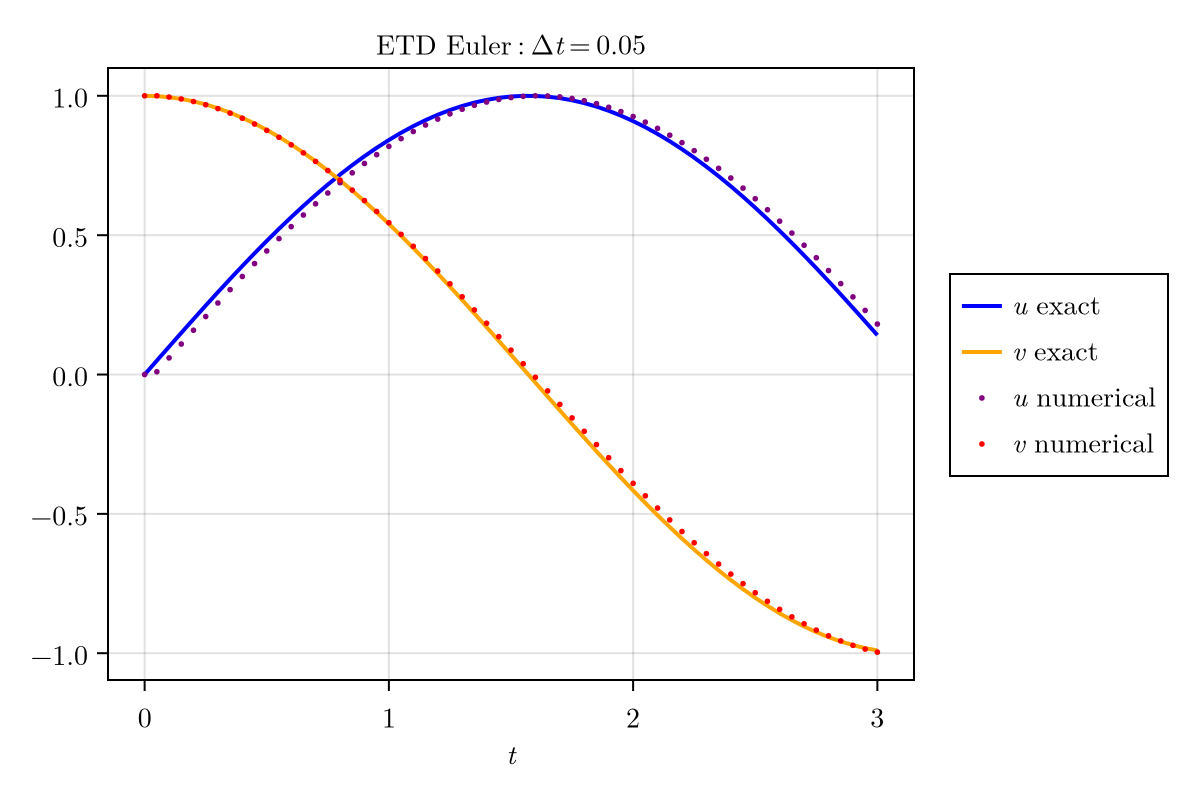

CairoMakie.Screen{IMAGE}


In [14]:
#Test ETD Euler using a *system* of 2 equations 
A = [-100.0 0.0; 0.0 -1.0]
u0 = [0.0, 1.0]

function f(u,p,t)
    f1 = cos(t) + 100*sin(t) + (u[1])^2 - (sin(t))^2 
    f2 = -sin(t) + cos(t) + u[1] * u[2] - sin(t) * cos(t)
    return [f1, f2]
end 

u_exact(t) = [sin(t), cos(t)]

tf = 3.0 
@time out = etd_euler(A, f, u0; Δt = 0.05, p = 1, tspan = (0, tf))

sol = out.u
t = out.t
Δt = out.Δt

u_num = getindex.(sol,1)
v_num = getindex.(sol,2)

ex_sol = u_exact.(t)
u_ex = getindex.(ex_sol, 1)
v_ex = getindex.(ex_sol, 2);

@printf("RMSE_u = %.4e\n", mean(sqrt.((u_ex .- u_num).^2))) 
@printf("RMSE_v = %.4e\n", mean(sqrt.((v_ex .- v_num).^2))) 

fig = Figure(size = (600,400))

Δt_str = @sprintf("%.2f", Δt)
ax = Axis(fig[1,1], xlabel = L"t", title = L"\textrm{ETD Euler:} Δt = %$(Δt_str)")
lines!(ax, t, u_ex, color = :blue, linewidth = 2, label = L"u \textrm{ exact}")
lines!(ax, t, v_ex, color = :orange, linewidth = 2, label = L"v \textrm{ exact}")

scatter!(ax, t, u_num, color = :purple, markersize = 4, label = L"u \textrm{ numerical}")
scatter!(ax, t, v_num, color = :red, markersize = 4, label = L"v \textrm{ numerical}")

Legend(fig[1,2], ax)
#axislegend(ax, position = :rt)
display(fig)